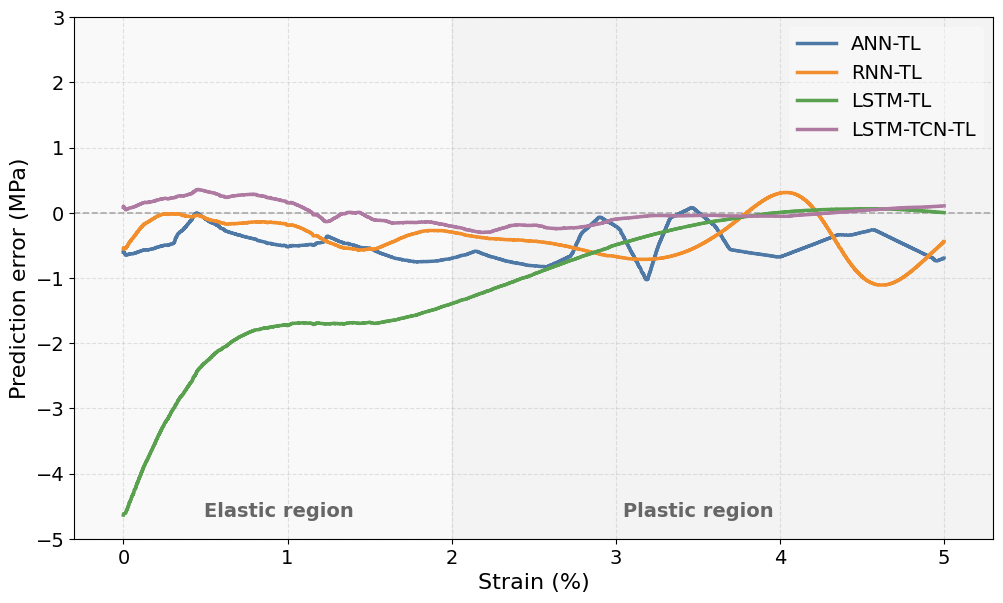

saved: tl_ann_fig/prediction/residual_trends_TL_combined.png


In [1]:
import os, numpy as np, pandas as pd, matplotlib.pyplot as plt
from scipy.signal import savgol_filter

# 可调样式参数（不改变数据）
STRAIN_MAX = 5
X_RANGE    = (-0.3, 5.3)
Y_LIMIT    = (-5, 3)  # 设为 None 自适应
SMOOTH_MAX_WIN = 101    # 平滑窗口最大奇数长度

# 四条曲线：迁移学习后的残差CSV（已按60-p导出）
series = [
    {'name': 'ANN-TL',      'csv': 'tl_ann_fig/prediction/residuals_ANN_TL.csv',         'color': '#4E79A7'},
    {'name': 'RNN-TL',      'csv': 'tl_rnn_fig/prediction/residuals_RNN_TL.csv',         'color': '#F28E2B'},
    {'name': 'LSTM-TL',     'csv': 'tl_lstm_fig/prediction/residuals_LSTM_TL.csv',       'color': '#59A14F'},
    {'name': 'LSTM-TCN-TL', 'csv': 'lstmtcn_tl_fig/prediction/residuals_LSTMTCN_TL.csv', 'color': '#AF7AA1'},
]

# tl_rnn_fig/prediction/residuals_RNN_TL.csv
# 

plt.figure(figsize=(10, 6))

# 背景色块（按你最新区间）
ax = plt.gca()
ax.axvspan(-0.3, 2, color='#F5F5F5', alpha=0.5, zorder=0)  # Elastic-like
ax.axvspan( 2, 5.3, color='#E8E8E8', alpha=0.5, zorder=0)  # Plastic-like

for s in series:
    if not os.path.exists(s['csv']):
        print('skip (not found):', s['csv']); 
        continue
    df = pd.read_csv(s['csv']).dropna()
    df = df[df['strain'] <= STRAIN_MAX].sort_values('strain')
    if len(df) < 5:
        print('skip (too few points):', s['name']); 
        continue

    x = df['strain'].values
    y = df['residual'].values

    # Savitzky–Golay 平滑（10%长度，上限SMOOTH_MAX_WIN，奇数；点少不平滑）
    n = len(y)
    if n >= 11:
        win = min(SMOOTH_MAX_WIN, max(11, (n//10)*2 + 1))
        y_smooth = savgol_filter(y, win, 2)
    else:
        y_smooth = y

    plt.plot(x, y_smooth, color=s['color'], linewidth=2.5, label=s['name'], zorder=2)

# A/B 标签放在色块下方（不随Y轴范围变化）
trans = ax.get_xaxis_transform()
ax.text(0.95, 0.035, 'Elastic region', transform=trans, ha='center', va='bottom',
        fontsize=14, fontweight='bold', color='#666666')
ax.text(3.50, 0.035, 'Plastic region', transform=trans, ha='center', va='bottom',
        fontsize=14, fontweight='bold', color='#666666')

# 零误差参考线 + 统一样式
plt.axhline(0, color='#A9A9A9', linestyle='--', linewidth=1.2, zorder=1)
plt.xlabel('Strain (%)', fontsize=16)
plt.ylabel('Prediction error (MPa)', fontsize=16)
plt.xticks(fontsize=14); plt.yticks(fontsize=14)
plt.grid(True, linestyle='--', alpha=0.35)

# 半透明图例（右上角）
leg = plt.legend(fontsize=14, loc='upper right', frameon=True, facecolor='white', edgecolor='none', framealpha=0.4)

# 轴范围
plt.xlim(*X_RANGE)
if Y_LIMIT is not None:
    plt.ylim(*Y_LIMIT)
    # 如需固定步长（例：2 MPa），打开下一行
    # plt.gca().set_yticks(np.arange(Y_LIMIT[0], Y_LIMIT[1] + 1e-9, 2))

# 保存
os.makedirs('tl_ann_fig/prediction', exist_ok=True)
out_path = os.path.join('tl_ann_fig', 'prediction', 'residual_trends_TL_combined.png')
plt.tight_layout(pad=0.6)
plt.savefig(out_path, dpi=300, bbox_inches='tight')
plt.show()
print('saved:', out_path)